<a href="https://colab.research.google.com/github/lilsane/telco_churn_prediction_using_SVM/blob/main/telco_churn_predict_using_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

folder_path = "/content/drive/MyDrive/ospyn_ml models/svm"
print(os.listdir(folder_path))

['Telco-Customer-Churn.csv', 'telco_churn_predict using svm.ipynb']


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/ospyn_ml models/svm/Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# drop unnecessary columns
df.drop(["customerID", "gender"], axis=1, inplace=True)

In [ ]:


# convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# remove missing rows
df.dropna(inplace=True)

# convert categorical columns to numeric
df = pd.get_dummies(df, drop_first=True)

# check result
print(df.shape)
print(df.head())

(7032, 30)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Partner_Yes  \
0              0       1           29.85         29.85         True   
1              0      34           56.95       1889.50        False   
2              0       2           53.85        108.15        False   
3              0      45           42.30       1840.75        False   
4              0       2           70.70        151.65        False   

   Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  \
0           False             False                            True   
1           False              True                           False   
2           False              True                           False   
3           False             False                            True   
4           False              True                           False   

   MultipleLines_Yes  InternetService_Fiber optic  ...  StreamingTV_Yes  \
0              False                        False  ...      

In [ ]:
from imblearn.over_sampling import SMOTE

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X, y)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

In [ ]:
#standardscaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(8260, 29)
(2066, 29)


In [ ]:
#train svm model
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [ ]:
#predict
y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)

In [ ]:
#evaluate
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[837 196]
 [171 862]]
              precision    recall  f1-score   support

       False       0.83      0.81      0.82      1033
        True       0.81      0.83      0.82      1033

    accuracy                           0.82      2066
   macro avg       0.82      0.82      0.82      2066
weighted avg       0.82      0.82      0.82      2066

Accuracy: 0.8223620522749274


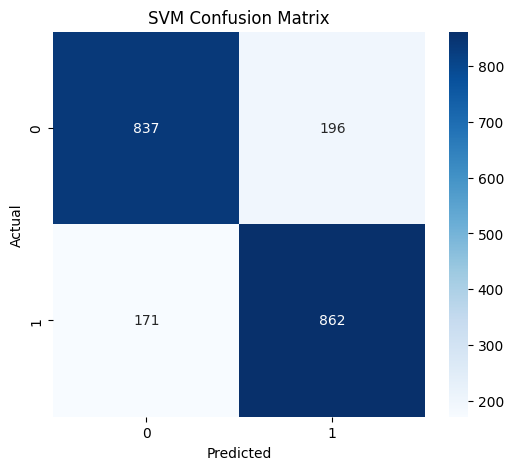

In [ ]:
#confusion matrix heatmap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

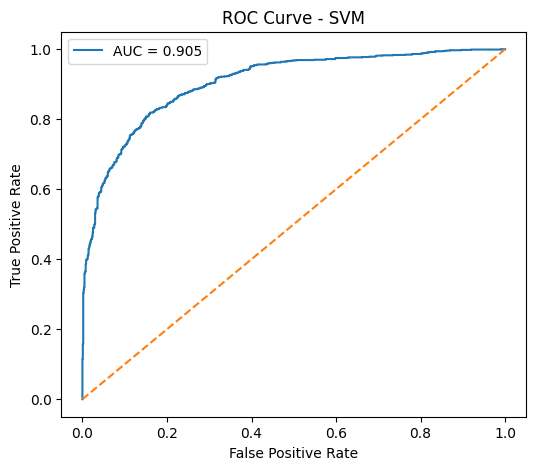

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [ ]:
print("Number of support vectors:", svm_model.n_support_)

Number of support vectors: [1809 1760]


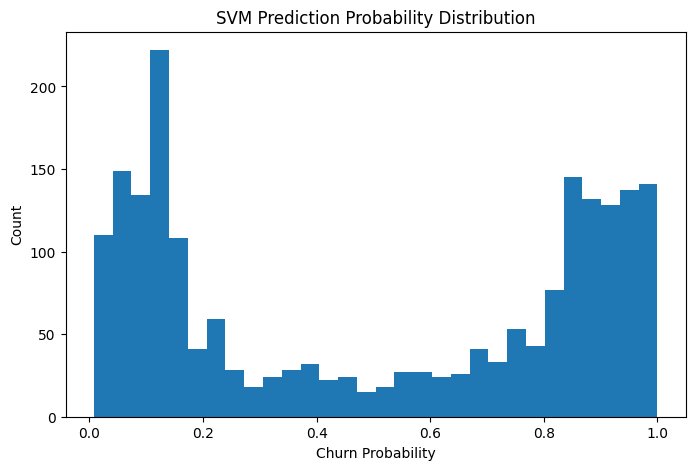

In [ ]:
#probability distribution plot
plt.figure(figsize=(8,5))
plt.hist(y_prob[:,1], bins=30)
plt.xlabel("Churn Probability")
plt.ylabel("Count")
plt.title("SVM Prediction Probability Distribution")
plt.show()

In [ ]:
def test_unseen_customer_svm():
    customer = pd.DataFrame(columns=X.columns)
    customer.loc[0] = 0

    # numerical inputs
    customer["SeniorCitizen"] = int(input("Senior Citizen? (1/0): "))
    customer["tenure"] = int(input("Tenure (0-72): "))
    customer["MonthlyCharges"] = float(input("Monthly Charges: "))
    customer["TotalCharges"] = float(input("Total Charges: "))

    # binary categorical inputs
    customer["Partner_Yes"] = int(input("Partner? (1/0): "))
    customer["Dependents_Yes"] = int(input("Dependents? (1/0): "))
    customer["PhoneService_Yes"] = int(input("Phone Service? (1/0): "))
    customer["MultipleLines_Yes"] = int(input("Multiple Lines? (1/0): "))
    customer["InternetService_Fiber optic"] = int(input("Fiber optic? (1/0): "))
    customer["OnlineSecurity_Yes"] = int(input("Online Security? (1/0): "))
    customer["OnlineBackup_Yes"] = int(input("Online Backup? (1/0): "))
    customer["DeviceProtection_Yes"] = int(input("Device Protection? (1/0): "))
    customer["TechSupport_Yes"] = int(input("Tech Support? (1/0): "))
    customer["StreamingTV_Yes"] = int(input("Streaming TV? (1/0): "))
    customer["StreamingMovies_Yes"] = int(input("Streaming Movies? (1/0): "))
    customer["Contract_One year"] = int(input("One year contract? (1/0): "))
    customer["Contract_Two year"] = int(input("Two year contract? (1/0): "))
    customer["PaperlessBilling_Yes"] = int(input("Paperless Billing? (1/0): "))
    customer["PaymentMethod_Electronic check"] = int(input("Electronic check? (1/0): "))
    customer["PaymentMethod_Mailed check"] = int(input("Mailed check? (1/0): "))

    # IMPORTANT → scaling
    customer_scaled = scaler.transform(customer)

    pred = svm_model.predict(customer_scaled)
    prob = svm_model.predict_proba(customer_scaled)

    print("\nPrediction:", "Churn" if pred[0] else "No Churn")
    print("Probability [No Churn, Churn]:", prob)

In [ ]:
test_unseen_customer_svm()

Senior Citizen? (1/0): 1
Tenure (0-72): 1
Monthly Charges: 117
Total Charges: 8000
Partner? (1/0): 1
Dependents? (1/0): 1
Phone Service? (1/0): 1
Multiple Lines? (1/0): 0
Fiber optic? (1/0): 0
Online Security? (1/0): 0
Online Backup? (1/0): 0
Device Protection? (1/0): 0
Tech Support? (1/0): 0
Streaming TV? (1/0): 0
Streaming Movies? (1/0): 0
One year contract? (1/0): 0
Two year contract? (1/0): 0
Paperless Billing? (1/0): 0
Electronic check? (1/0): 0
Mailed check? (1/0): 0

Prediction: No Churn
Probability [No Churn, Churn]: [[0.99695198 0.00304802]]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


GridSearchCV(cv=3, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy', verbose=2)

In [ ]:
from sklearn.svm import SVC

best_svm = SVC(
    C=10,
    kernel='linear',
    probability=True,
    random_state=42
)

best_svm.fit(X_train_scaled, y_train)

SVC(C=10, kernel='linear', probability=True, random_state=42)

In [ ]:
y_pred_best = best_svm.predict(X_test_scaled)
y_prob_best = best_svm.predict_proba(X_test_scaled)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))

[[852 181]
 [187 846]]
              precision    recall  f1-score   support

       False       0.82      0.82      0.82      1033
        True       0.82      0.82      0.82      1033

    accuracy                           0.82      2066
   macro avg       0.82      0.82      0.82      2066
weighted avg       0.82      0.82      0.82      2066

Optimized Accuracy: 0.8218780251694094


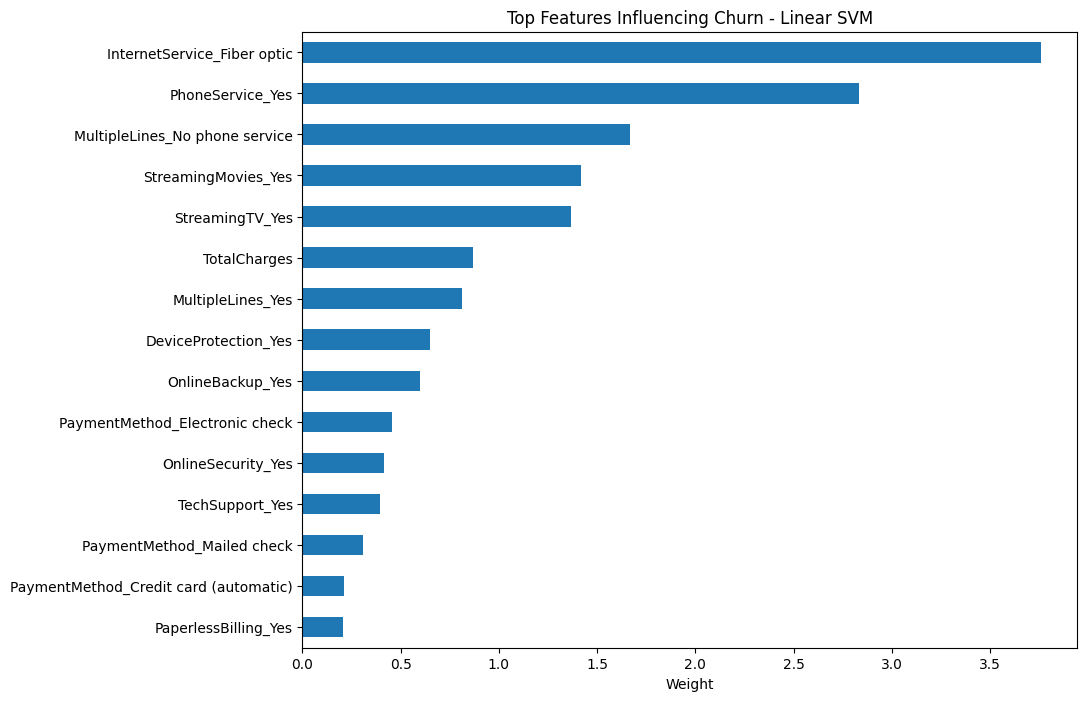

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

weights = pd.Series(
    best_svm.coef_[0],
    index=X_train.columns
).sort_values()

plt.figure(figsize=(10,8))
weights.tail(15).plot(kind='barh')
plt.title("Top Features Influencing Churn - Linear SVM")
plt.xlabel("Weight")
plt.show()

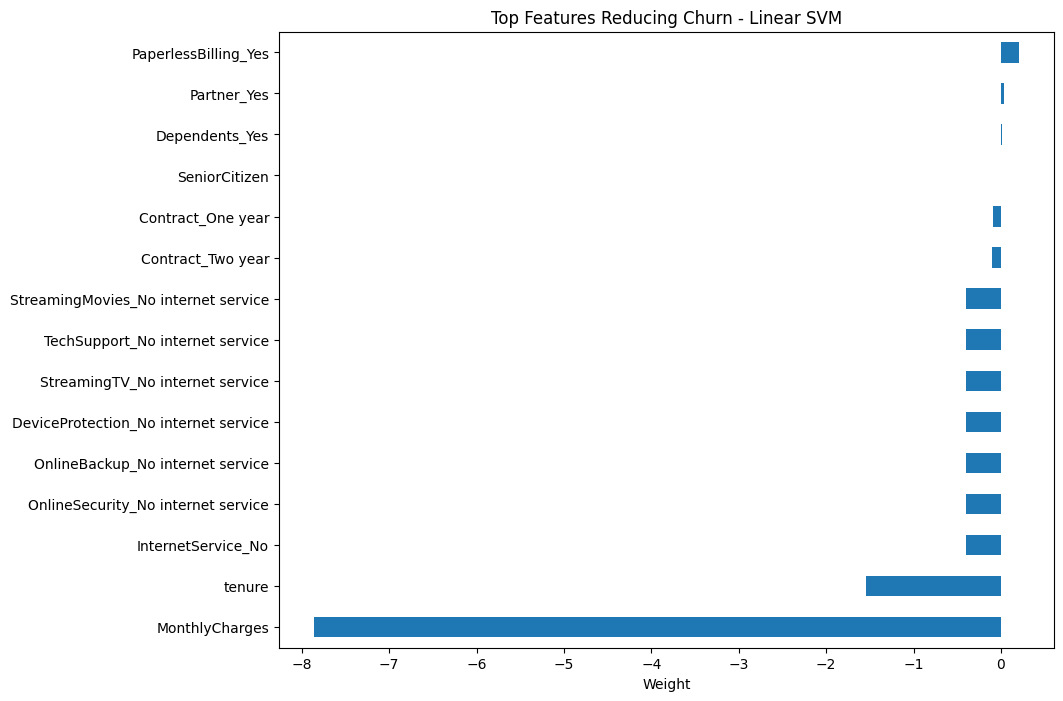

In [ ]:
weights = pd.Series(
    best_svm.coef_[0],
    index=X_train.columns
).sort_values()

plt.figure(figsize=(10,8))
weights.head(15).plot(kind='barh')
plt.title("Top Features Reducing Churn - Linear SVM")
plt.xlabel("Weight")
plt.show()